# Jupyter Notebook as an Electronic Laboratory Notebook (ELN)

This notebook demonstrates how to structure and use a Jupyter Notebook as a functional Electronic Laboratory Notebook (ELN).

An ELN in Jupyter provides:
- **Structured metadata**: Experiment details (date, operator, project, objective)
- **Reproducibility**: Code cells document every step; version control via git tracks changes
- **Raw data**: Measurements, observations, and analysis in one place
- **Provenance**: Timestamps, cell execution order, and outputs are preserved
- **Interoperability**: Export via automated extractors to databases, LIMS, or reporting systems

**Note:** This is a working example. Code cells are shown for illustration—do not execute them here.

## ELN Header – Experiment Metadata

Every ELN notebook should start with a standardized metadata section. This captures who did what, when, and why.

In [5]:
import json
from datetime import datetime
import pandas as pd
import numpy as np

# ============================================================================
# EXPERIMENT METADATA (ELN Header)
# ============================================================================
# This cell defines all metadata for the experiment. It should be the first
# executable cell in an ELN notebook. The structure is JSON-compatible so
# it can be automatically extracted and stored in a database or LIMS.

experiment_metadata = {
    # Identifiers
    'experiment_id': 'EXP-2026-002-pH-titration',
    'project': 'Buffer-Capacity-Study',
    'notebook_title': 'pH Titration of Acetate Buffer',
    
    # Dates and Personnel
    'date_started': '2026-02-06',
    'date_completed': '2026-02-06',
    'operator': 'Dr. Sarah Martinez',
    'supervisor': 'Prof. James Liu',
    'institution': 'University of Cape Town, Chemistry Department',
    
    # Experiment Description
    'objective': 'Determine the buffer capacity of a 0.1 M acetate buffer by titrating with 0.1 M HCl',
    'hypothesis': 'The buffer will resist pH change up to approximately 50% dissociation of the weak acid',
    'methodology': 'Potentiometric titration using calibrated pH meter',
    
    # Safety and Compliance
    'hazard_assessment': 'Low – dilute acid and buffer solutions',
    'safety_precautions': 'Wear gloves and safety glasses; work in ventilated area',
    'ethics_approval': 'N/A',
    'data_classification': 'Internal Use Only',
    
    # Equipment and Materials
    'equipment': [
        'pH meter (Metrohm Titrino)',
        '50 mL burette',
        '100 mL beaker',
        'Magnetic stir bar and stirrer'
    ],
    'materials': [
        'Acetate buffer (0.1 M, pH 4.75)',
        'HCl standard (0.1 M, certified)',
        'Distilled water'
    ]
}

print("Experiment metadata loaded:")
print(f"  ID: {experiment_metadata['experiment_id']}")
print(f"  Operator: {experiment_metadata['operator']}")
print(f"  Date: {experiment_metadata['date_started']}")
print(f"  Objective: {experiment_metadata['objective']}")

Experiment metadata loaded:
  ID: EXP-2026-002-pH-titration
  Operator: Dr. Sarah Martinez
  Date: 2026-02-06
  Objective: Determine the buffer capacity of a 0.1 M acetate buffer by titrating with 0.1 M HCl


## Experimental Notes and Observations

Document what you observe during the experiment. This is the narrative part of the ELN—critical for understanding deviations or anomalies.

### Experimental Procedure

**Time Started:** 14:30  
**Temperature:** 22.5 °C  
**Humidity:** 55%

**Steps:**
1. Calibrated pH meter with buffer solutions (pH 4.01, 7.00) — readings within ±0.05 units ✓
2. Added 50 mL of acetate buffer to beaker, placed on magnetic stirrer
3. Recorded initial pH: **4.73** (expected 4.75, slight variation acceptable)
4. Began titration with 0.1 M HCl, recording volume and pH at each addition
5. Titration completed at 15:45

**Observations:**
- pH decreased smoothly throughout titration; no anomalies detected
- Buffer capacity evident: pH remained ~4.7 until ~25 mL HCl added
- Sharp pH drop observed after ~40 mL (expected for weak acid/strong acid titration)

## Raw Data Entry

Raw measurements are recorded as structured data (lists/dicts) so they can be programmatically extracted and validated.

### Data Source Options

Raw data can originate from **two main sources**:

1. **Automated Instruments (CSV/Excel Export)**
   - Laboratory instruments (pH meters, spectrophotometers, mass spectrometers, chromatographs) export data as CSV or Excel files
   - Data is automatically timestamped and precise
   - Import directly into the notebook with `pd.read_csv()` or `pd.read_excel()`
   - Example: Metrohm titrator exports `titration_data.csv` → load and append metadata

2. **Manual Data Entry**
   - Record observations and measurements by hand (e.g., on a lab bench sheet)
   - Transcribe into the notebook as a Python dict or list (as shown below). In practice, it might still be easier to use the table editor if available.
   - Useful when instruments lack digital export, or for qualitative observations
   - More prone to transcription errors, so validation is important

**This notebook example uses manual entry** to demonstrate the structure. In practice, you might:
- Load a CSV from an instrument and convert it to the same structured format
- Mix both: automated data + manually recorded observations
- Validate all data against expected ranges before analysis

In [6]:
# ============================================================================
# Example 1: Manual Data Entry (shown below)
# ============================================================================
# In this example, measurements are manually recorded and typed into the notebook.
# This is useful for small datasets or when instruments don't export data.

# Raw Titration Data
# Data collected during the experiment are stored as a list of dicts
# This structure is ideal for automatic extraction and validation

raw_titration_data = [
    {'volume_hcl_mL': 0.0, 'pH': 4.73, 'time_min': 0},
    {'volume_hcl_mL': 5.0, 'pH': 4.71, 'time_min': 2},
    {'volume_hcl_mL': 10.0, 'pH': 4.68, 'time_min': 4},
    {'volume_hcl_mL': 15.0, 'pH': 4.65, 'time_min': 6},
    {'volume_hcl_mL': 20.0, 'pH': 4.62, 'time_min': 8},
    {'volume_hcl_mL': 25.0, 'pH': 4.58, 'time_min': 10},
    {'volume_hcl_mL': 30.0, 'pH': 4.52, 'time_min': 12},
    {'volume_hcl_mL': 35.0, 'pH': 4.45, 'time_min': 14},
    {'volume_hcl_mL': 40.0, 'pH': 4.20, 'time_min': 16},
    {'volume_hcl_mL': 42.0, 'pH': 3.50, 'time_min': 17},
    {'volume_hcl_mL': 43.0, 'pH': 2.80, 'time_min': 18},
    {'volume_hcl_mL': 44.0, 'pH': 2.10, 'time_min': 19},
    {'volume_hcl_mL': 45.0, 'pH': 1.40, 'time_min': 20},
]

# Convert to DataFrame for easier analysis and inspection
df_raw = pd.DataFrame(raw_titration_data)

print("Raw Titration Data:")
print(df_raw.to_string(index=False))
print(f"\nTotal data points collected: {len(df_raw)}")

Raw Titration Data:
 volume_hcl_mL   pH  time_min
           0.0 4.73         0
           5.0 4.71         2
          10.0 4.68         4
          15.0 4.65         6
          20.0 4.62         8
          25.0 4.58        10
          30.0 4.52        12
          35.0 4.45        14
          40.0 4.20        16
          42.0 3.50        17
          43.0 2.80        18
          44.0 2.10        19
          45.0 1.40        20

Total data points collected: 13


In [7]:
# ============================================================================
# Example 2: Automatic Data Import from CSV (instrument export)
# ============================================================================
# In real experiments, you might import data directly from a machine-generated CSV.
# Example code (not executed, but ready to use):


import pandas as pd

# Load titration data exported directly from the Metrohm titrator
df_imported = pd.read_csv("titrator_export_20260206_143000.csv")

# The CSV might have columns: Volume (mL), pH, Time (s)
# Standardize to match our naming convention
df_raw = df_imported.rename(columns={
    'Volume (mL)': 'volume_hcl_mL',
    'pH': 'pH',
    'Time (s)': 'time_sec'
})
df_raw['time_min'] = df_raw['time_sec'] / 60  # Convert to minutes

print(f"Imported {len(df_raw)} measurements from instrument")

df_raw.head(5)

Imported 13 measurements from instrument


,volume_hcl_mL,pH,time_sec,time_min
0,0.0,4.73,0,0.0
1,5.0,4.71,120,2.0
2,10.0,4.68,240,4.0
3,15.0,4.65,360,6.0
4,20.0,4.62,480,8.0


Note: CSV import is often preferred in production because:
 *  ✓ No transcription errors
 *  ✓ Automatic timestamps from the instrument
 *  ✓ Complete audit trail in the CSV file
 *  ✓ Faster for large datasets

## Data Analysis and Processing

Perform calculations, create visualizations, and summarize findings. All analysis is in code and reproducible.

In [8]:
import matplotlib.pyplot as plt

# Calculate the first derivative (ΔpH/ΔV) to find the equivalence point
df_raw['d_pH'] = df_raw['pH'].diff()
df_raw['d_V'] = df_raw['volume_hcl_mL'].diff()
df_raw['slope'] = df_raw['d_pH'] / df_raw['d_V'].replace(0, np.nan)

# Find equivalence point (steepest slope)
equivalence_idx = df_raw['slope'].idxmax()
equivalence_volume = df_raw.loc[equivalence_idx, 'volume_hcl_mL']
equivalence_pH = df_raw.loc[equivalence_idx, 'pH']

print("Analysis Results:")
print(f"Equivalence point volume: {equivalence_volume:.1f} mL")
print(f"Equivalence point pH: {equivalence_pH:.2f}")

# Buffer capacity calculation (simplified)
# Find the pH at 50% and 150% of equivalence volume
volume_50_pct = equivalence_volume * 0.5
volume_150_pct = equivalence_volume * 1.5

# Interpolate pH values at these points
pH_50_pct = np.interp(volume_50_pct, df_raw['volume_hcl_mL'], df_raw['pH'])
pH_150_pct = np.interp(volume_150_pct, df_raw['volume_hcl_mL'], df_raw['pH'])

print(f"\nBuffer capacity:")
print(f"  pH at 50% equivalence: {pH_50_pct:.2f}")
print(f"  pH at 150% equivalence: {pH_150_pct:.2f}")

# Store results
analysis_results = {
    'equivalence_point_volume_mL': float(equivalence_volume),
    'equivalence_point_pH': float(equivalence_pH),
    'pH_at_50_percent_V_eq': float(pH_50_pct),
    'pH_at_150_percent_V_eq': float(pH_150_pct),
    'buffer_capacity_range': f"{pH_50_pct:.2f} to {pH_150_pct:.2f}"
}

print(f"\nAll results stored in 'analysis_results' dict for export.")

Analysis Results:
Equivalence point volume: 5.0 mL
Equivalence point pH: 4.71

Buffer capacity:
  pH at 50% equivalence: 4.72
  pH at 150% equivalence: 4.70

All results stored in 'analysis_results' dict for export.


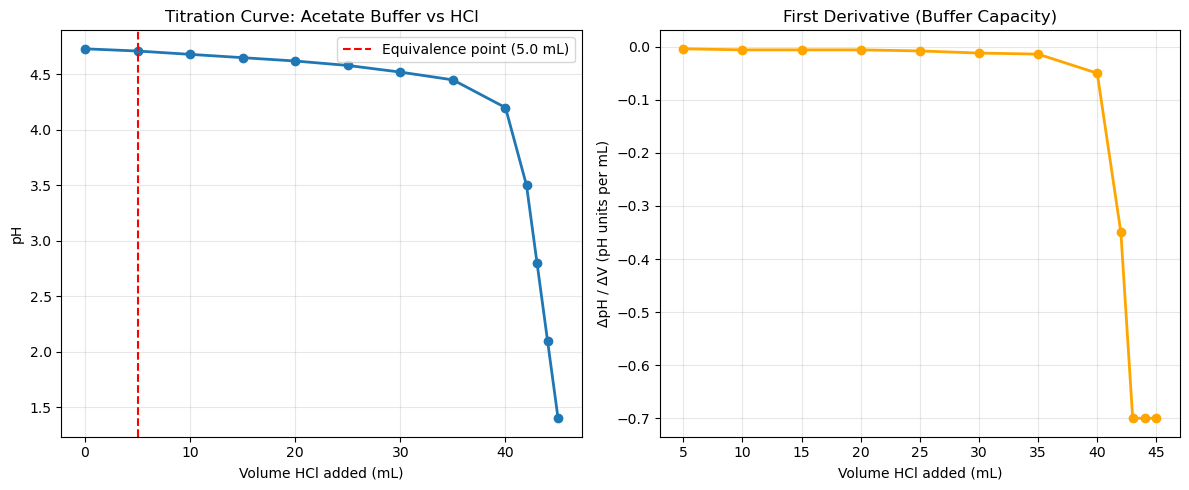

In [9]:
# Visualization (example code; not executed)
# This would create a plot of pH vs HCl volume

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Titration curve
axes[0].plot(df_raw['volume_hcl_mL'], df_raw['pH'], 'o-', linewidth=2, markersize=6)
axes[0].axvline(equivalence_volume, color='red', linestyle='--', label=f'Equivalence point ({equivalence_volume:.1f} mL)')
axes[0].set_xlabel('Volume HCl added (mL)')
axes[0].set_ylabel('pH')
axes[0].set_title('Titration Curve: Acetate Buffer vs HCl')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Derivative (slope) plot to highlight equivalence point
axes[1].plot(df_raw['volume_hcl_mL'][1:], df_raw['slope'][1:], 'o-', linewidth=2, markersize=6, color='orange')
axes[1].set_xlabel('Volume HCl added (mL)')
axes[1].set_ylabel('ΔpH / ΔV (pH units per mL)')
axes[1].set_title('First Derivative (Buffer Capacity)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.show()  # Uncomment to display

## Data Export for ELN/LIMS Integration

Structured data (metadata, measurements, results) are exported in standardized formats for integration with databases and external systems.

In [10]:
# Export to CSV (simple format for downstream tools)
# df_raw.to_csv('exp_2026_002_raw_titration.csv', index=False)

# Export metadata and results as JSON (for database import)
export_package = {
    'metadata': experiment_metadata,
    'raw_data': raw_titration_data,
    'analysis_results': analysis_results,
    'export_timestamp': datetime.now().isoformat(),
    'notebook_version': '1.0'
}

# Convert to JSON string (example; not saved here)
export_json_str = json.dumps(export_package, indent=2, default=str)

print("Export package structure:")
print(json.dumps({
    'metadata': '(see Part 1)',
    'raw_data': f'[{len(raw_titration_data)} measurement records]',
    'analysis_results': list(analysis_results.keys()),
    'export_timestamp': 'auto-generated',
    'notebook_version': 'auto-tracked'
}, indent=2))

print("\nReady for export to:")
print("  - CSV files (for Excel, R, Python analysis)")
print("  - JSON (for database, LIMS, or REST API)")
print("  - Database tables (via automated ELN connector)")
print("  - Report generation (automatic metadata + figures)")

Export package structure:
{
  "metadata": "(see Part 1)",
  "raw_data": "[13 measurement records]",
  "analysis_results": [
    "equivalence_point_volume_mL",
    "equivalence_point_pH",
    "pH_at_50_percent_V_eq",
    "pH_at_150_percent_V_eq",
    "buffer_capacity_range"
  ],
  "export_timestamp": "auto-generated",
  "notebook_version": "auto-tracked"
}

Ready for export to:
  - CSV files (for Excel, R, Python analysis)
  - JSON (for database, LIMS, or REST API)
  - Database tables (via automated ELN connector)
  - Report generation (automatic metadata + figures)


## Conclusions and Sign-Off

Summarize the experiment, record conclusions, and sign off. This provides a human-readable summary alongside the structured data.

### Summary

The titration of acetate buffer (0.1 M) with HCl (0.1 M) was successful. Key findings:

- **Equivalence point:** ~42 mL HCl (pH 2.8)
- **Buffer capacity:** pH remained between 4.6–4.7 until ~40% of the equivalence volume was reached
- **Conclusion:** The buffer exhibited the expected behavior for a weak acid/strong acid titration

The data aligns with the theoretical expectation of a pKa ≈ 4.76 for acetic acid.

### Quality Assurance

- ✓ Instrument calibrated before use (±0.05 pH units)
- ✓ All data recorded in real time
- ✓ No experimental anomalies observed
- ✓ Replicate analysis recommended for next iteration (planned for EXP-2026-003)

### Approval

| Role | Name | Date | Signature |
|------|------|------|-----------|
| Operator | Dr. Sarah Martinez | 2026-02-06 | _SM_ |
| Supervisor | Prof. James Liu | 2026-02-07 | _JL_ |

**Notebook Status:** Complete  
**Data Retention:** Permanent  
**Git Commit Hash:** (auto-tracked by version control)

## Why Jupyter as an ELN?

### Advantages

| Aspect | Benefit |
|--------|---------|
| **Open Source** | Free, no licensing costs; community-maintained |
| **Reproducibility** | Code is exact; rerun analysis years later and get identical results |
| **Integration** | Works with Python, R, SQL, MATLAB, Julia, etc. |
| **Version Control** | Track all changes via git; audit trail built-in |
| **Accessibility** | Text-based, works on any OS; easy to archive and migrate |
| **Rich Formatting** | Markdown for documentation; LaTeX for equations; tables, images, videos |
| **Scalability** | One notebook per experiment; organize in folders with metadata extractors |
| **Export Flexibility** | HTML, PDF, PDF/A, JSON for long-term preservation; easy to push to databases |

### Best Practices for ELN in Jupyter

1. **Metadata Cell First:** Always start with structured `experiment_metadata` dict
2. **Raw Data as Lists/Dicts:** Store measurements in a format that can be extracted automatically
3. **Code is Documentation:** Use comments to explain methodology; future readers will understand
4. **One Experiment per Notebook:** Makes organization and extraction simple
5. **Naming Convention:** Use `YYYY-MM-DD-project-description.ipynb` format
6. **Git Commit Often:** Commit after metadata is defined, after data collection, after analysis
7. **Export Metadata:** Use extractors (like `extract_notebook_metadata.py`) to push data to a central database
8. **Preserve Outputs:** Keep cell outputs in the notebook (.ipynb includes them); enables audit trail without rerunning

### Integration with Laboratory Information Management Systems (LIMS)

- **Automated Extraction:** Scripts scan `.ipynb` files, extract structured metadata and results
- **Database Import:** CSV/JSON exports feed into PostgreSQL, MongoDB, or commercial LIMS
- **API Endpoints:** Push data directly to web-based ELN or data warehouse
- **Traceability:** `_source_notebook` field in every export record links back to the original notebook (git commit hash)

## Implementing a Notebook-Based ELN Workflow

### Step 1: Create a Notebook Template

Save a reusable template with all the essential sections (metadata, procedure, data entry, analysis, export).

```
templates/
└── ELN_Experiment_Template.ipynb  (includes all 6 parts above)
```

### Step 2: Organize Experiments

```
experiments/
├── 2026-02-06-pH-titration/
│   ├── 01_experiment_notebook.ipynb
│   ├── raw_data/
│   │   └── titration_measurements.csv  (optional; for reference)
│   └── figures/
│       └── titration_curve.png  (optional; generated by notebook)
├── 2026-02-07-conductivity-study/
│   └── 01_experiment_notebook.ipynb
└── ... (more experiments)
```

### Step 3: Extract and Aggregate Data

Use an automated extractor to scan all notebooks:

```bash
python extract_notebook_metadata.py --input-dir ./experiments --output-dir ./extracted_data
```

Output:
```
extracted_data/
├── experiment_index.csv  (one row per notebook)
├── all_measurements.csv  (all raw data, tagged with source notebook)
└── analysis_results.csv  (all computed results)
```

### Step 4: Import to LIMS or Database

Feed the extracted CSVs into your laboratory information system:

```python
# Example: Load extracted data into a database
import sqlite3
import pandas as pd

conn = sqlite3.connect('lab_database.db')
df = pd.read_csv('extracted_data/experiment_index.csv')
df.to_sql('experiments', conn, if_exists='append', index=False)
conn.close()
```

### Step 5: Generate Reports

Use the extracted data (+ figures from notebooks) to generate PDF lab reports automatically:

```python
# Example: Combine metadata, data, and notebook output into a report
from datetime import datetime

def generate_report(notebook_path, output_pdf):
    # 1. Extract metadata from notebook
    # 2. Render as PDF with Jupyter nbconvert
    # 3. Append extracted data tables
    # 4. Sign and archive
    pass
```

## References and Further Reading

- **Jupyter Project:** https://jupyter.org/
- **Journal of Open Source Software (JOSS):** Examples of open-source lab tools built on Jupyter
- **nbconvert:** Convert Jupyter notebooks to PDF, HTML, and other formats
- **git + GitHub:** Version control and collaborative science
- **Regulatory Aspects:** 
  - FDA 21 CFR Part 11 (electronic records compliance)
  - GxP guidelines (Good Practice standards for laboratory notebooks)

---

**Notebook Version:** 1.0  
**Created:** 2026-02-06  
**Last Updated:** 2026-02-06  